In [1]:
import kagglehub
import os

# Đường dẫn lưu data
base_dir = r'data'
os.environ['KAGGLEHUB_CACHE'] = base_dir

path = kagglehub.dataset_download("haitranquangofficial/vietnamese-online-news-dataset")
print("Path to dataset files:", path)

d:\anaconda3\envs\it\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: data\datasets\haitranquangofficial\vietnamese-online-news-dataset\versions\1


In [2]:
import pandas as pd

files_in_path = os.listdir(path)
json_file_name = 'news_dataset.json'
full_json_path = os.path.join(path, json_file_name)

try:
    df = pd.read_json(full_json_path)
    print(f"Đã load dataset với {df.shape[0]} dòng và {df.shape[1]} cột.")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file JSON tại {full_json_path}. Vui lòng kiểm tra lại tên file.")
except Exception as e:
    print(f"Lỗi đọc file: {e}")

Đã load dataset với 184539 dòng và 10 cột.


### Tổng quan về data

In [3]:
df.head()

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
0,218270,,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",3,0,docbao.vn,"Tên cướp tiệm vàng tại Huế là đại uý công an, ...",Pháp luật,https://docbao.vn/phap-luat/ten-cuop-tiem-vang...,2022-08-01 09:09:22.817308
1,218269,(Nguồn: Sina),"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",1,0,vtc.vn,"Bỏ qua mạng 5G, Nga tiến thẳng từ 4G lên 6G",Sống kết nối,https://vtc.vn/bo-qua-mang-5g-nga-tien-thang-t...,2022-08-01 09:09:21.181469
2,218268,Hồ Sỹ Anh,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,3,0,thanhnien.vn,Địa phương nào đứng đầu cả nước tổng điểm 3 mô...,Giáo dục,https://thanhnien.vn/dia-phuong-nao-dung-dau-c...,2022-08-01 09:09:15.311901
3,218267,Ngọc Ánh,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,1,0,vnexpress,Người chết trong mưa lũ 'nghìn năm có một' ở M...,Thế giới,https://vnexpress.net/nguoi-chet-trong-mua-lu-...,2022-08-01 09:09:02.211498
4,218266,HẢI YẾN - MINH LÝ,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,12,0,soha,"Hải Phòng: Hình ảnh xe ""điên"" gây tai nạn liên...",Thời sự - Xã hội,https://soha.vn/hai-phong-hinh-anh-xe-dien-gay...,2022-08-01 09:09:01.601170


In [4]:
print(f"Kích thước DataFrame: {df.shape}")

print("\nSố lượng giá trị thiếu hụt trên mỗi cột:")
print(df.isnull().sum())
for col in df.columns:
    empty_str_count = sum(df[col].apply(lambda x: 1 if isinstance(x, str) and x.strip() == '' else 0))
    if empty_str_count > 0:
        print(f"  - Cột '{col}' có {empty_str_count} chuỗi rỗng ('')")

Kích thước DataFrame: (184539, 10)

Số lượng giá trị thiếu hụt trên mỗi cột:
id                 0
author             0
content            0
picture_count      0
processed          0
source             5
title              0
topic              0
url                0
crawled_at       414
dtype: int64
  - Cột 'author' có 36740 chuỗi rỗng ('')
  - Cột 'content' có 23468 chuỗi rỗng ('')
  - Cột 'title' có 19 chuỗi rỗng ('')
  - Cột 'topic' có 39488 chuỗi rỗng ('')


In [5]:
df['topic'] = df['topic'].fillna('Chưa phân loại')
df['topic'] = df['topic'].replace(['Unknown', 'None', '', None], 'Chưa phân loại')

topic_mapping = {
    'THẾ GIỚI': 'Thế giới', 'XÃ HỘI': 'Xã hội', 'THỜI SỰ': 'Thời sự',
    'PHÁP LUẬT': 'Pháp luật', 'THỂ THAO': 'Thể thao', 'GIẢI TRÍ': 'Giải trí',
    'GIÁO DỤC': 'Giáo dục', 'KINH DOANH': 'Kinh doanh', 'CÔNG NGHỆ': 'Công nghệ',
    'ĐỜI SỐNG': 'Đời sống', 'SỨC KHỎE': 'Sức khỏe', 'VĂN HÓA': 'Văn hóa'
}
df['topic'] = df['topic'].replace(topic_mapping)
df['topic'] = df['topic'].apply(lambda x: str(x).strip().capitalize() if x != 'Chưa phân loại' else x)

df['source'] = df['source'].fillna('Khác')
df['source'] = df['source'].replace(['', 'Unknown', None], 'Khác')
df['source'] = df['source'].str.strip().str.lower()

df['crawled_at_parsed'] = pd.to_datetime(df['crawled_at'], errors='coerce')


In [6]:
df['title_word_count'] = df['title'].fillna('').apply(lambda x: len(str(x).split()))
df['content_word_count'] = df['content'].fillna('').apply(lambda x: len(str(x).split()))

print("Thống kê độ dài Tiêu đề (Số từ)")
print(df['title_word_count'].describe())


Thống kê độ dài Tiêu đề (Số từ)
count    184539.000000
mean         14.418264
std           5.317415
min           0.000000
25%          11.000000
50%          14.000000
75%          17.000000
max         248.000000
Name: title_word_count, dtype: float64


C:\Users\duong\AppData\Local\Temp\ipykernel_18952\1521324986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


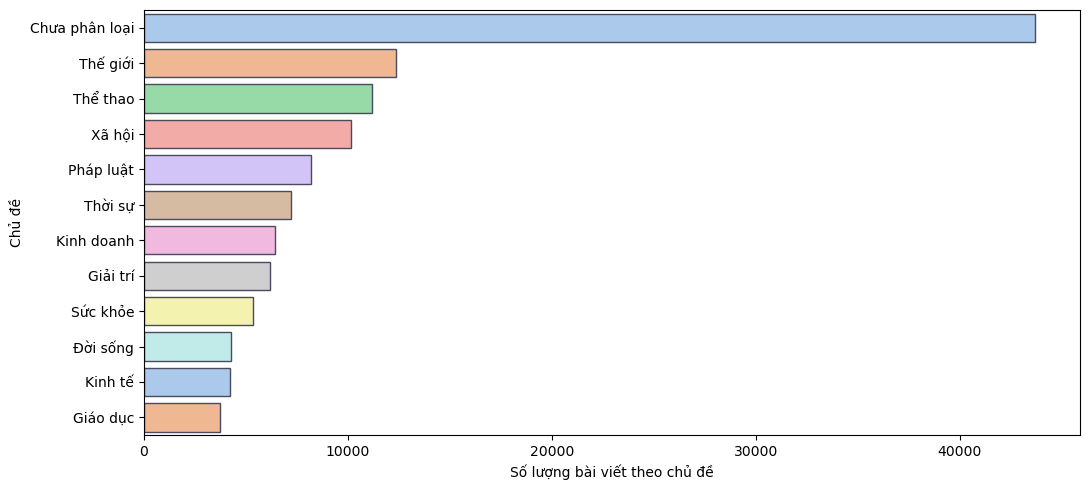

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 5))
top_topics = df['topic'].value_counts().head(12)

sns.barplot(
    x=top_topics.values, 
    y=top_topics.index, 
    palette=sns.color_palette("pastel", len(top_topics)),
    edgecolor='#4A4A60',
)
plt.xlabel("Số lượng bài viết theo chủ đề")
plt.ylabel("Chủ đề")
plt.tight_layout()
plt.show()

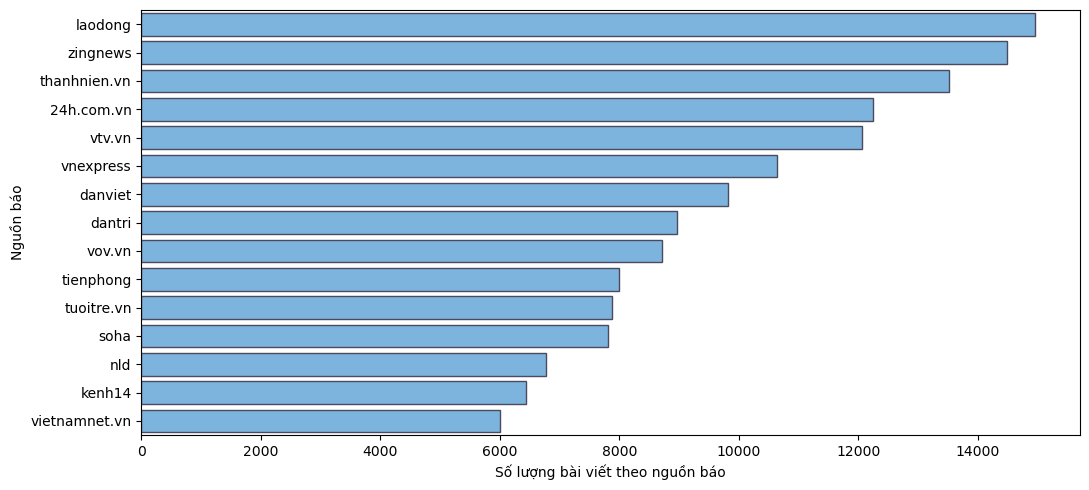

In [8]:
plt.figure(figsize=(11, 5))
top_sources = df['source'].value_counts().head(15)

sns.barplot(
    x=top_sources.values, 
    y=top_sources.index, 
    color="#6DB6ED", 
    edgecolor='#4A4A60',
)
plt.xlabel("Số lượng bài viết theo nguồn báo")
plt.ylabel("Nguồn báo")
plt.tight_layout()
plt.show()

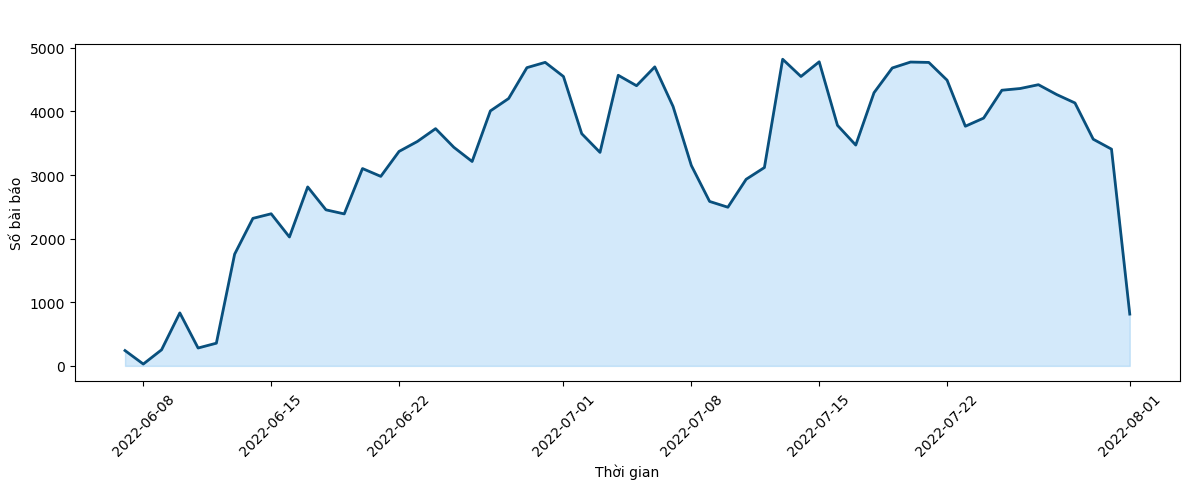

In [9]:
plt.figure(figsize=(12, 5))
df_time = df.dropna(subset=['crawled_at_parsed'])
timeline = df_time.groupby(df_time['crawled_at_parsed'].dt.date).size()

plt.plot(timeline.index, timeline.values, color="#09507D", linewidth=2, label='Thu thập theo ngày')
plt.fill_between(timeline.index, timeline.values, color="#2392E7", alpha=0.2)

plt.title("Tần suất Thu thập Dữ liệu theo Thời gian (Crawl Frequency)", pad=15, weight='bold', color='#FFFFFF')
plt.xlabel("Thời gian")
plt.ylabel("Số bài báo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

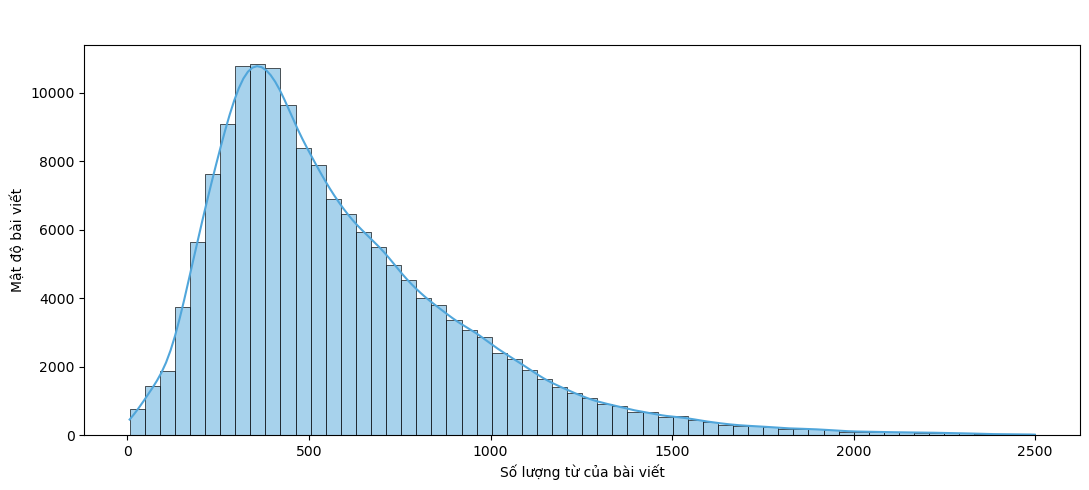

In [10]:
plt.figure(figsize=(11, 5))
filtered_words = df[(df['content_word_count'] > 5) & (df['content_word_count'] < 2500)]['content_word_count']

sns.histplot(
    filtered_words, 
    bins=60, 
    kde=True, 
    color="#50A6DB", 
    edgecolor="#0F1215",
    linewidth=0.5
)

plt.title("Phân bố Độ dài Nội dung Bài viết (Content Word Count)", pad=15, weight='bold', color='#FFFFFF')
plt.xlabel("Số lượng từ của bài viết")
plt.ylabel("Mật độ bài viết")
plt.tight_layout()
plt.show()